# Loading Libraries

In [2]:
import pandas as pd
import torch

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device 

'cuda'

## Reading Data 

In [6]:
with open("training-text.txt" , "r" , encoding="utf-8") as f:

    data = f.read()



print(f"Number of charachters in the text : {len(data)}")
print(f"First 100 charachters : \n {data[:99]}")

Number of charachters in the text : 20478
First 100 charachters : 
 I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


### Different technqies of tokenizations 

- Using Regex

In [7]:
import re
text = "Hello, world.  This,  is a test"

## Split based on whitespace (\s)

result_1 = re.split(r"(\s)", text)

print(result_1)


['Hello,', ' ', 'world.', ' ', '', ' ', 'This,', ' ', '', ' ', 'is', ' ', 'a', ' ', 'test']


>> This is not the optimal way of tokenizing words 
- Because each word isnt a pure word, it may contain special charachters or puncutations like `Hello,` or `world.`
- `We dont want to remove capitalization, since capital letter may give the model the sence, of starting a new sentence or discover this word is noun not verb ...etc`



In [11]:
## split (tokenize) if it found whitespace(\s) or special charachter `comma and period`


result_2 = re.split(r"([,.] |\s)",text)
print (result_2)

['Hello', ', ', 'world', '. ', '', ' ', 'This', ', ', '', ' ', 'is', ' ', 'a', ' ', 'test']


In [38]:
for i in result_2:
    if i.strip():
        print(i)
    else:
        print(f"print : {i}")

Hello
, 
world
. 
print : 
print :  
This
, 
print : 
print :  
is
print :  
a
print :  
test


In [42]:
## Removing extra space in the sentence 
# if word.strip() means : if word.strip() is not empty after removal the leading/trailing white space  
# since strip is worked on word level  or `value by value` either in charachter level on string, or value in list 

result_3 = [word for word in result_2 if word.strip()]
result_3

['Hello', ', ', 'world', '. ', 'This', ', ', 'is', 'a', 'test']

In [46]:
## Make the tokenizer split either on a whitespace (\s) or any special charachters

text_2 = "Hello,  world. Is this-- a test?"
result_4 = re.split(r'([,.:;?_!"()\']|--|\s )' , text_2)
result_4

['Hello', ',', '', '  ', 'world', '.', ' Is this', '--', ' a test', '?', '']

In [48]:
result_4 = [word for word in result_4 if word.strip()]
result_4

['Hello', ',', 'world', '.', ' Is this', '--', ' a test', '?']

In [49]:
result_4 = [word.strip() for word in result_4 if word.strip()]
result_4

['Hello', ',', 'world', '.', 'Is this', '--', 'a test', '?']

**Apply the last tokenizer to the training data**

In [78]:
preprocessing = re.split(r'([,.:;?_!"()\']|--|\s)',data)
preprocessing

['I',
 ' ',
 'HAD',
 ' ',
 'always',
 ' ',
 'thought',
 ' ',
 'Jack',
 ' ',
 'Gisburn',
 ' ',
 'rather',
 ' ',
 'a',
 ' ',
 'cheap',
 ' ',
 'genius',
 '--',
 'though',
 ' ',
 'a',
 ' ',
 'good',
 ' ',
 'fellow',
 ' ',
 'enough',
 '--',
 'so',
 ' ',
 'it',
 ' ',
 'was',
 ' ',
 'no',
 ' ',
 'great',
 ' ',
 'surprise',
 ' ',
 'to',
 ' ',
 'me',
 ' ',
 'to',
 ' ',
 'hear',
 ' ',
 'that',
 ',',
 '',
 ' ',
 'in',
 ' ',
 'the',
 ' ',
 'height',
 ' ',
 'of',
 ' ',
 'his',
 ' ',
 'glory',
 ',',
 '',
 ' ',
 'he',
 ' ',
 'had',
 ' ',
 'dropped',
 ' ',
 'his',
 ' ',
 'painting',
 ',',
 '',
 ' ',
 'married',
 ' ',
 'a',
 ' ',
 'rich',
 ' ',
 'widow',
 ',',
 '',
 ' ',
 'and',
 ' ',
 'established',
 ' ',
 'himself',
 ' ',
 'in',
 ' ',
 'a',
 ' ',
 'villa',
 ' ',
 'on',
 ' ',
 'the',
 ' ',
 'Riviera',
 '.',
 '',
 ' ',
 '',
 '(',
 'Though',
 ' ',
 'I',
 ' ',
 'rather',
 ' ',
 'thought',
 ' ',
 'it',
 ' ',
 'would',
 ' ',
 'have',
 ' ',
 'been',
 ' ',
 'Rome',
 ' ',
 'or',
 ' ',
 'Florence',
 '.',
 '',


In [79]:
data[:100]

'I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no g'

### **what does this code do exactly ??**

```python

[i.strip() for i in preprocessing if i.strip()]
```

if i.strip 
- It is a condition, if u remove trailing and leading zeros, does it returns string or empty string? if string --> return true, empty return false
- It acts as a mask, it returns either true or false, in case of true --> keep it , fasle --> drop it 
- so i.strip just keep all words even yo drop trailing and leading whitespace


i.strip()

- remove the trailing and leading whitespace


In [80]:
preprocessing = [i.strip() for i in preprocessing if i.strip()]
preprocessing

['I',
 'HAD',
 'always',
 'thought',
 'Jack',
 'Gisburn',
 'rather',
 'a',
 'cheap',
 'genius',
 '--',
 'though',
 'a',
 'good',
 'fellow',
 'enough',
 '--',
 'so',
 'it',
 'was',
 'no',
 'great',
 'surprise',
 'to',
 'me',
 'to',
 'hear',
 'that',
 ',',
 'in',
 'the',
 'height',
 'of',
 'his',
 'glory',
 ',',
 'he',
 'had',
 'dropped',
 'his',
 'painting',
 ',',
 'married',
 'a',
 'rich',
 'widow',
 ',',
 'and',
 'established',
 'himself',
 'in',
 'a',
 'villa',
 'on',
 'the',
 'Riviera',
 '.',
 '(',
 'Though',
 'I',
 'rather',
 'thought',
 'it',
 'would',
 'have',
 'been',
 'Rome',
 'or',
 'Florence',
 '.',
 ')',
 '"',
 'The',
 'height',
 'of',
 'his',
 'glory',
 '"',
 '--',
 'that',
 'was',
 'what',
 'the',
 'women',
 'called',
 'it',
 '.',
 'I',
 'can',
 'hear',
 'Mrs',
 '.',
 'Gideon',
 'Thwing',
 '--',
 'his',
 'last',
 'Chicago',
 'sitter',
 '--',
 'deploring',
 'his',
 'unaccountable',
 'abdication',
 '.',
 '"',
 'Of',
 'course',
 'it',
 "'",
 's',
 'going',
 'to',
 'send',
 't

In [81]:
print(f"Length of data after preprocessing: {len(preprocessing)}")

Length of data after preprocessing: 4689


In [82]:
preprocessing[:30]

['I',
 'HAD',
 'always',
 'thought',
 'Jack',
 'Gisburn',
 'rather',
 'a',
 'cheap',
 'genius',
 '--',
 'though',
 'a',
 'good',
 'fellow',
 'enough',
 '--',
 'so',
 'it',
 'was',
 'no',
 'great',
 'surprise',
 'to',
 'me',
 'to',
 'hear',
 'that',
 ',',
 'in']

### Create our vocabs 

In [87]:
## remove non-unique values and sort them

all_words = sorted(set(preprocessing))
all_words

['!',
 '"',
 "'",
 '(',
 ')',
 ',',
 '--',
 '.',
 ':',
 ';',
 '?',
 'A',
 'Ah',
 'Among',
 'And',
 'Are',
 'Arrt',
 'As',
 'At',
 'Be',
 'Begin',
 'Burlington',
 'But',
 'By',
 'Carlo',
 'Chicago',
 'Claude',
 'Come',
 'Croft',
 'Destroyed',
 'Devonshire',
 'Don',
 'Dubarry',
 'Emperors',
 'Florence',
 'For',
 'Gallery',
 'Gideon',
 'Gisburn',
 'Gisburns',
 'Grafton',
 'Greek',
 'Grindle',
 'Grindles',
 'HAD',
 'Had',
 'Hang',
 'Has',
 'He',
 'Her',
 'Hermia',
 'His',
 'How',
 'I',
 'If',
 'In',
 'It',
 'Jack',
 'Jove',
 'Just',
 'Lord',
 'Made',
 'Miss',
 'Money',
 'Monte',
 'Moon-dancers',
 'Mr',
 'Mrs',
 'My',
 'Never',
 'No',
 'Now',
 'Nutley',
 'Of',
 'Oh',
 'On',
 'Once',
 'Only',
 'Or',
 'Perhaps',
 'Poor',
 'Professional',
 'Renaissance',
 'Rickham',
 'Riviera',
 'Rome',
 'Russian',
 'Sevres',
 'She',
 'Stroud',
 'Strouds',
 'Suddenly',
 'That',
 'The',
 'Then',
 'There',
 'They',
 'This',
 'Those',
 'Though',
 'Thwing',
 'Thwings',
 'To',
 'Usually',
 'Venetian',
 'Victor',
 '

In [88]:
len(all_words)

1130

In [96]:
vocab = {token:integer for integer,token in enumerate(all_words)}
vocab

{'!': 0,
 '"': 1,
 "'": 2,
 '(': 3,
 ')': 4,
 ',': 5,
 '--': 6,
 '.': 7,
 ':': 8,
 ';': 9,
 '?': 10,
 'A': 11,
 'Ah': 12,
 'Among': 13,
 'And': 14,
 'Are': 15,
 'Arrt': 16,
 'As': 17,
 'At': 18,
 'Be': 19,
 'Begin': 20,
 'Burlington': 21,
 'But': 22,
 'By': 23,
 'Carlo': 24,
 'Chicago': 25,
 'Claude': 26,
 'Come': 27,
 'Croft': 28,
 'Destroyed': 29,
 'Devonshire': 30,
 'Don': 31,
 'Dubarry': 32,
 'Emperors': 33,
 'Florence': 34,
 'For': 35,
 'Gallery': 36,
 'Gideon': 37,
 'Gisburn': 38,
 'Gisburns': 39,
 'Grafton': 40,
 'Greek': 41,
 'Grindle': 42,
 'Grindles': 43,
 'HAD': 44,
 'Had': 45,
 'Hang': 46,
 'Has': 47,
 'He': 48,
 'Her': 49,
 'Hermia': 50,
 'His': 51,
 'How': 52,
 'I': 53,
 'If': 54,
 'In': 55,
 'It': 56,
 'Jack': 57,
 'Jove': 58,
 'Just': 59,
 'Lord': 60,
 'Made': 61,
 'Miss': 62,
 'Money': 63,
 'Monte': 64,
 'Moon-dancers': 65,
 'Mr': 66,
 'Mrs': 67,
 'My': 68,
 'Never': 69,
 'No': 70,
 'Now': 71,
 'Nutley': 72,
 'Of': 73,
 'Oh': 74,
 'On': 75,
 'Once': 76,
 'Only': 77,
 '

In [99]:
for token,int in vocab.items():
    print(f"({token},{int})")
    if int >=50:
        break


(!,0)
(",1)
(',2)
((,3)
(),4)
(,,5)
(--,6)
(.,7)
(:,8)
(;,9)
(?,10)
(A,11)
(Ah,12)
(Among,13)
(And,14)
(Are,15)
(Arrt,16)
(As,17)
(At,18)
(Be,19)
(Begin,20)
(Burlington,21)
(But,22)
(By,23)
(Carlo,24)
(Chicago,25)
(Claude,26)
(Come,27)
(Croft,28)
(Destroyed,29)
(Devonshire,30)
(Don,31)
(Dubarry,32)
(Emperors,33)
(Florence,34)
(For,35)
(Gallery,36)
(Gideon,37)
(Gisburn,38)
(Gisburns,39)
(Grafton,40)
(Greek,41)
(Grindle,42)
(Grindles,43)
(HAD,44)
(Had,45)
(Hang,46)
(Has,47)
(He,48)
(Her,49)
(Hermia,50)


In [100]:
int_to_str = {integer:tokens for integer,tokens in enumerate(all_words)}
int_to_str

{0: '!',
 1: '"',
 2: "'",
 3: '(',
 4: ')',
 5: ',',
 6: '--',
 7: '.',
 8: ':',
 9: ';',
 10: '?',
 11: 'A',
 12: 'Ah',
 13: 'Among',
 14: 'And',
 15: 'Are',
 16: 'Arrt',
 17: 'As',
 18: 'At',
 19: 'Be',
 20: 'Begin',
 21: 'Burlington',
 22: 'But',
 23: 'By',
 24: 'Carlo',
 25: 'Chicago',
 26: 'Claude',
 27: 'Come',
 28: 'Croft',
 29: 'Destroyed',
 30: 'Devonshire',
 31: 'Don',
 32: 'Dubarry',
 33: 'Emperors',
 34: 'Florence',
 35: 'For',
 36: 'Gallery',
 37: 'Gideon',
 38: 'Gisburn',
 39: 'Gisburns',
 40: 'Grafton',
 41: 'Greek',
 42: 'Grindle',
 43: 'Grindles',
 44: 'HAD',
 45: 'Had',
 46: 'Hang',
 47: 'Has',
 48: 'He',
 49: 'Her',
 50: 'Hermia',
 51: 'His',
 52: 'How',
 53: 'I',
 54: 'If',
 55: 'In',
 56: 'It',
 57: 'Jack',
 58: 'Jove',
 59: 'Just',
 60: 'Lord',
 61: 'Made',
 62: 'Miss',
 63: 'Money',
 64: 'Monte',
 65: 'Moon-dancers',
 66: 'Mr',
 67: 'Mrs',
 68: 'My',
 69: 'Never',
 70: 'No',
 71: 'Now',
 72: 'Nutley',
 73: 'Of',
 74: 'Oh',
 75: 'On',
 76: 'Once',
 77: 'Only',
 7

## Tokenizer Class

In [ ]:
class SimpleTokenizerV1:

    def __init__(self,vocab):
        self.int_to_str = {integer:token for integer,token in enumerate(vocab)}
        self.str_to_int = {token:integer for integer,token in enumerate(vocab)}

    def encode(self,text):

        preprocessing = re.split(r'([,.:;?_!"()\']|--|\s)',text)
        preprocessing = [i.strip() for i in preprocessing if i.strip()]
        idx = [self.str_to_int[i] for i in preprocessing]

        return idx
    
    def decode(self,idx):

        text = " ".join([self.int_to_str[ix] for ix in idx])
        # Replace spaces before any punctuation
        text = re.sub(r'\s+([,.?!"()\'])',r'\1',text)
        
        return text


In [119]:
tokenizer = SimpleTokenizerV1(all_words)
text = """ "It's the last he painted, you know, "
            Mrs. Gisburn said with pardonable pride."""

ids = tokenizer.encode(text)
print(ids)

[1, 56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]


In [118]:
print(tokenizer.decode(ids))

" It' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.


In [138]:
new_text = "Hello, do you like tea?"
print(tokenizer.decode(new_text))

KeyError: 'H'

> **This error because `Hello` is not included in our Vocabulary**

#### Our vocab dont contain any hello word

In [148]:
a = 0
for i in data.split():
    if i == "hello" or i =="Hello" or i =="h" or i =="H":
        i+=1

print(f"The number that hello appear in our vocab : {a}")

The number that hello appear in our vocab : 0


In [146]:
a

0

## Adding Special tokens

- |unk| --> To deal with the words that is not seen in the vocab or during training
- |endoftext| --> to separate 2 unrelated texts,books or sentence, so the model understand better that those books are not related to each other

### What is the difference between `append` vs `Extend`

- append at each item as a list 
- extend at each item as an item 

for example

```python 
x=[1,2]
y=[3,4]

x.append(y)
# [1,2,[3,4]]

x.extend(y)
# [1,2,3,4]
```

In [164]:
z=[1,2]
c = [3,4]

append_op = z.append(c)
print(f"Append operation : {z}")


Append operation : [1, 2, [3, 4]]


In [166]:
z=[1,2]
c = [3,4]

z.extend(c)
print(f"Extend operation : {z}")

Extend operation : [1, 2, 3, 4]


In [167]:
all_tokens = sorted(list(set(preprocessing)))
all_tokens.extend(["<|endoftext|>" , "<|unk|>"])

vocab = {token:integer for integer,token in enumerate(all_tokens)}
print(len(vocab))

1132


In [169]:
vocab

{'!': 0,
 '"': 1,
 "'": 2,
 '(': 3,
 ')': 4,
 ',': 5,
 '--': 6,
 '.': 7,
 ':': 8,
 ';': 9,
 '?': 10,
 'A': 11,
 'Ah': 12,
 'Among': 13,
 'And': 14,
 'Are': 15,
 'Arrt': 16,
 'As': 17,
 'At': 18,
 'Be': 19,
 'Begin': 20,
 'Burlington': 21,
 'But': 22,
 'By': 23,
 'Carlo': 24,
 'Chicago': 25,
 'Claude': 26,
 'Come': 27,
 'Croft': 28,
 'Destroyed': 29,
 'Devonshire': 30,
 'Don': 31,
 'Dubarry': 32,
 'Emperors': 33,
 'Florence': 34,
 'For': 35,
 'Gallery': 36,
 'Gideon': 37,
 'Gisburn': 38,
 'Gisburns': 39,
 'Grafton': 40,
 'Greek': 41,
 'Grindle': 42,
 'Grindles': 43,
 'HAD': 44,
 'Had': 45,
 'Hang': 46,
 'Has': 47,
 'He': 48,
 'Her': 49,
 'Hermia': 50,
 'His': 51,
 'How': 52,
 'I': 53,
 'If': 54,
 'In': 55,
 'It': 56,
 'Jack': 57,
 'Jove': 58,
 'Just': 59,
 'Lord': 60,
 'Made': 61,
 'Miss': 62,
 'Money': 63,
 'Monte': 64,
 'Moon-dancers': 65,
 'Mr': 66,
 'Mrs': 67,
 'My': 68,
 'Never': 69,
 'No': 70,
 'Now': 71,
 'Nutley': 72,
 'Of': 73,
 'Oh': 74,
 'On': 75,
 'Once': 76,
 'Only': 77,
 '

> The normal vocab was 1130
>> Now it becomes, 1132 due to addition of 2 more vocab

In [177]:
[token for num,token in enumerate(list(vocab.items())[-5:])]

[('younger', 1127),
 ('your', 1128),
 ('yourself', 1129),
 ('<|endoftext|>', 1130),
 ('<|unk|>', 1131)]

**Note**

- `In SimpleTokenizerV1`
    - We used all_Words in the __init__

- In the newer version we can use `all_tokens` which equivalent to `all_words`
- But for change, we will use `vocab` directly

In [205]:
t1 = "Hello World, Are you okay"
p = re.split(r'([,.:;?_!"()\']|--|\s)',t1)
p = [i.strip() for i in p if i.strip()]
print(p)


['Hello', 'World', ',', 'Are', 'you', 'okay']


In [192]:
v_r = {numb:token for token,numb in vocab.items()}
v_r

{0: '!',
 1: '"',
 2: "'",
 3: '(',
 4: ')',
 5: ',',
 6: '--',
 7: '.',
 8: ':',
 9: ';',
 10: '?',
 11: 'A',
 12: 'Ah',
 13: 'Among',
 14: 'And',
 15: 'Are',
 16: 'Arrt',
 17: 'As',
 18: 'At',
 19: 'Be',
 20: 'Begin',
 21: 'Burlington',
 22: 'But',
 23: 'By',
 24: 'Carlo',
 25: 'Chicago',
 26: 'Claude',
 27: 'Come',
 28: 'Croft',
 29: 'Destroyed',
 30: 'Devonshire',
 31: 'Don',
 32: 'Dubarry',
 33: 'Emperors',
 34: 'Florence',
 35: 'For',
 36: 'Gallery',
 37: 'Gideon',
 38: 'Gisburn',
 39: 'Gisburns',
 40: 'Grafton',
 41: 'Greek',
 42: 'Grindle',
 43: 'Grindles',
 44: 'HAD',
 45: 'Had',
 46: 'Hang',
 47: 'Has',
 48: 'He',
 49: 'Her',
 50: 'Hermia',
 51: 'His',
 52: 'How',
 53: 'I',
 54: 'If',
 55: 'In',
 56: 'It',
 57: 'Jack',
 58: 'Jove',
 59: 'Just',
 60: 'Lord',
 61: 'Made',
 62: 'Miss',
 63: 'Money',
 64: 'Monte',
 65: 'Moon-dancers',
 66: 'Mr',
 67: 'Mrs',
 68: 'My',
 69: 'Never',
 70: 'No',
 71: 'Now',
 72: 'Nutley',
 73: 'Of',
 74: 'Oh',
 75: 'On',
 76: 'Once',
 77: 'Only',
 7

In [203]:
[i for i in vocab]

['!',
 '"',
 "'",
 '(',
 ')',
 ',',
 '--',
 '.',
 ':',
 ';',
 '?',
 'A',
 'Ah',
 'Among',
 'And',
 'Are',
 'Arrt',
 'As',
 'At',
 'Be',
 'Begin',
 'Burlington',
 'But',
 'By',
 'Carlo',
 'Chicago',
 'Claude',
 'Come',
 'Croft',
 'Destroyed',
 'Devonshire',
 'Don',
 'Dubarry',
 'Emperors',
 'Florence',
 'For',
 'Gallery',
 'Gideon',
 'Gisburn',
 'Gisburns',
 'Grafton',
 'Greek',
 'Grindle',
 'Grindles',
 'HAD',
 'Had',
 'Hang',
 'Has',
 'He',
 'Her',
 'Hermia',
 'His',
 'How',
 'I',
 'If',
 'In',
 'It',
 'Jack',
 'Jove',
 'Just',
 'Lord',
 'Made',
 'Miss',
 'Money',
 'Monte',
 'Moon-dancers',
 'Mr',
 'Mrs',
 'My',
 'Never',
 'No',
 'Now',
 'Nutley',
 'Of',
 'Oh',
 'On',
 'Once',
 'Only',
 'Or',
 'Perhaps',
 'Poor',
 'Professional',
 'Renaissance',
 'Rickham',
 'Riviera',
 'Rome',
 'Russian',
 'Sevres',
 'She',
 'Stroud',
 'Strouds',
 'Suddenly',
 'That',
 'The',
 'Then',
 'There',
 'They',
 'This',
 'Those',
 'Though',
 'Thwing',
 'Thwings',
 'To',
 'Usually',
 'Venetian',
 'Victor',
 '

In [ ]:
p = [item if item in vocab else "Unk" for item in p]
p

['Unk', 'Unk', ',', 'Are', 'you', 'Unk']

In [215]:
class SimpleTokenizerV2:

    def __init__(self,vocab):
        self.str_to_int = vocab
        self.int_to_str = {num:token for token,num in vocab.items()}

    def encode(self,text):
        preprocessing = re.split(r'([,.:;?_!"()\']|--|\s)',text)
        preprocessing = [i.strip() for i in preprocessing if i.strip()]

        ## Repalce any unknown token with <|unk|>
        preprocessing = [item if item in self.str_to_int else "<|unk|>" for item in preprocessing]

        idx = [self.str_to_int[s] for s in preprocessing]
        return idx
    
    def decode(self,ids):
        text = " ".join([self.int_to_str[id] for id in ids])

        # Replace spaces before any punctuation
        text = re.sub(r'\s+([,.?!"()\'])',r'\1',text)

        return text
    
        



In [236]:
t1 = "Hello , do you like tea?"
t2 = "In the sunlit terrace of the palace"

t_final = " <|endoftext|> ".join((t1,t2))
print(t_final)

Hello , do you like tea? <|endoftext|> In the sunlit terrace of the palace


### Lets use the SimpleTokenizerV2 

In [238]:
tokenizer=SimpleTokenizerV2(vocab)
print(tokenizer.encode(t_final))

[1131, 5, 355, 1126, 628, 975, 10, 1130, 55, 988, 956, 983, 722, 988, 1131]


In [239]:
print(tokenizer.decode(tokenizer.encode(t_final)))

<|unk|>, do you like tea? <|endoftext|> In the sunlit terrace of the <|unk|>


## BPE Tokenizer

- Instead of simple token we have
- We will use the tokenizer which GPT-2, GPT-3 used for training

**BPE Tokenizer** 
-Its code is relatively complex, for that we will use `tiktoken` lib
- BPE tokenizer dont have special token suchas as `unk` or `endoftext` because its used subrowds or words as a token


In [241]:
from importlib.metadata import version
import tiktoken

print(f"Tiktoken version : {version('tiktoken')}")

Tiktoken version : 0.11.0


**Usage of Tiktoken Tokenizer is the same as SimpleTokenizerV2**

In [245]:
tokenizer = tiktoken.get_encoding("gpt2")
tokenizer


<Encoding 'gpt2'>

In [270]:
text_to_test = ("Hello, do you like tea? <|endoftext|> In the sunlit terraces" " of someunknownPlace.")
idxs = tokenizer.encode(text_to_test , allowed_special={"<|endoftext|>"})
print(idxs)

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 286, 617, 34680, 27271, 13]


In [269]:
print(tokenizer.decode(idxs))

Hello, do you like tea? <|endoftext|> In the sunlit terraces of someunknownPlace.


**Exercise :2.1**

In [271]:
w = "Akwirw ier"
i = tokenizer.encode(w)
print(i)

[33901, 86, 343, 86, 220, 959]


In [272]:
print(tokenizer.decode(i))

Akwirw ier


## Create the Input-Target Pairs

### First we will use the `BPE` tokenizer to tokenize our dataset

In [276]:
enc_text = tokenizer.encode(data)
print(f"Length of our Dataset Using BPE : {len(enc_text)}")

Length of our Dataset Using BPE : 5145


In [286]:
enc_sample = enc_text[50:]
enc_sample

[290,
 4920,
 2241,
 287,
 257,
 4489,
 64,
 319,
 262,
 34686,
 41976,
 13,
 357,
 10915,
 314,
 2138,
 1807,
 340,
 561,
 423,
 587,
 10598,
 393,
 28537,
 2014,
 198,
 198,
 1,
 464,
 6001,
 286,
 465,
 13476,
 1,
 438,
 5562,
 373,
 644,
 262,
 1466,
 1444,
 340,
 13,
 314,
 460,
 3285,
 9074,
 13,
 46606,
 536,
 5469,
 438,
 14363,
 938,
 4842,
 1650,
 353,
 438,
 2934,
 489,
 3255,
 465,
 48422,
 540,
 450,
 67,
 3299,
 13,
 366,
 5189,
 1781,
 340,
 338,
 1016,
 284,
 3758,
 262,
 1988,
 286,
 616,
 4286,
 705,
 1014,
 510,
 26,
 475,
 314,
 836,
 470,
 892,
 286,
 326,
 11,
 1770,
 13,
 8759,
 2763,
 438,
 1169,
 2994,
 284,
 943,
 17034,
 318,
 477,
 314,
 892,
 286,
 526,
 383,
 1573,
 11,
 319,
 9074,
 13,
 536,
 5469,
 338,
 11914,
 11,
 33096,
 663,
 4808,
 3808,
 62,
 355,
 996,
 484,
 547,
 12548,
 287,
 281,
 13079,
 410,
 12523,
 286,
 22353,
 13,
 843,
 340,
 373,
 407,
 691,
 262,
 9074,
 13,
 536,
 48819,
 508,
 25722,
 276,
 13,
 11161,
 407,
 262,
 40123,
 18113,


### Creating the Input-Target pairs

In [287]:
context_size = 4
x = enc_sample[:context_size]
y = enc_sample[1: context_size+1]

print(f"x: {x}")
print(f"y :     {y}")

x: [290, 4920, 2241, 287]
y :     [4920, 2241, 287, 257]


In [288]:
for i in range(1,context_size+1):
    x= enc_sample[:i]
    y= enc_sample[i]
    print(f"{x} --> {y}")

[290] --> 4920
[290, 4920] --> 2241
[290, 4920, 2241] --> 287
[290, 4920, 2241, 287] --> 257


In [289]:
for i in range(1,context_size+1):
    x= enc_sample[:i]
    y= enc_sample[i]
    print(f"{tokenizer.decode(x)} --> {tokenizer.decode([y])}")

 and -->  established
 and established -->  himself
 and established himself -->  in
 and established himself in -->  a


In [292]:
enc_sample = enc_text[:100]

In [304]:
context_size=4
stride = 3
for i in range(0,len(enc_sample),3):
    x= enc_sample[i:i+context_size]
    y= enc_sample[i+1:i+context_size+1]
    print(f"{tokenizer.decode(x)} --> {tokenizer.decode(y)}")

I HAD always -->  HAD always thought
 always thought Jack G -->  thought Jack Gis
 Gisburn rather --> isburn rather a
 rather a cheap genius -->  a cheap genius--
 genius--though a --> --though a good
 a good fellow enough -->  good fellow enough--
 enough--so it --> --so it was
 it was no great -->  was no great surprise
 great surprise to me -->  surprise to me to
 me to hear that -->  to hear that,
 that, in the --> , in the height
 the height of his -->  height of his glory
 his glory, he -->  glory, he had
 he had dropped his -->  had dropped his painting
 his painting, married -->  painting, married a
 married a rich widow -->  a rich widow,
 widow, and established --> , and established himself
 established himself in a -->  himself in a vill
 a villa on -->  villa on the
 on the Riviera -->  the Riviera.
iera. (Though --> . (Though I
Though I rather thought -->  I rather thought it
 thought it would have -->  it would have been
 have been Rome or -->  been Rome or Florence
 or F

## Dataset Class


In [312]:
import torch 
from torch.utils.data import Dataset,DataLoader



class GPTDatasetV1(Dataset):

    def __init__(self,txt,tokenizer,max_length,stride):
        self.input_ids = []
        self.target_ids= []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt)

        for i in range(0,len(token_ids) - max_length,stride):

            input_chunk = token_ids[i:i+max_length]
            target_chunk = token_ids[i+1:i+max_length+1]

            self.input_ids.append(torch.Tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]
    
    




        

### Create a dataloader to create batches with input and targets
 

In [308]:
data

'I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a rich widow, and established himself in a villa on the Riviera. (Though I rather thought it would have been Rome or Florence.)\n\n"The height of his glory"--that was what the women called it. I can hear Mrs. Gideon Thwing--his last Chicago sitter--deploring his unaccountable abdication. "Of course it\'s going to send the value of my picture \'way up; but I don\'t think of that, Mr. Rickham--the loss to Arrt is all I think of." The word, on Mrs. Thwing\'s lips, multiplied its _rs_ as though they were reflected in an endless vista of mirrors. And it was not only the Mrs. Thwings who mourned. Had not the exquisite Hermia Croft, at the last Grafton Gallery show, stopped me before Gisburn\'s "Moon-dancers" to say, with tears in her eyes: "We shall not look upon its like again"?\n\nWell!--even 

In [ ]:
def create_dataloader_v1(txt,
                         batch_size = 4 ,
                         max_length=256,
                         stride=128,
                         shuffle=True,
                         drop_last = True, # if the last batch smaller than batch_size --> drop it
                         num_workers=0 ):
    
    tokenizer = tiktoken.get_encoding("gpt2")
    
    dataset = GPTDatasetV1(txt,tokenizer,max_length,stride)

    dataloader = DataLoader(dataset=dataset,
                            batch_size=batch_size,
                            shuffle=shuffle,
                            drop_last=drop_last,
                            num_workers=num_workers)
    
    
    return dataloader



#### Testing the DataLoader and Dataset

In [313]:
with open("training-text.txt" , "r" , encoding="utf-8") as f:
    data =f.read()

dataloader = create_dataloader_v1(data, batch_size=1 , max_length=4, stride=1 , shuffle=False)

dataloader

### Convert Dataloader into iterator using `iter`
### after make it iterator --> we can fetch it using `next`

In [314]:
### Convert Dataloader into iterator using `iter`
### after make it iterator --> we can fetch it using `next`
data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)

[tensor([[  40.,  367., 2885., 1464.]]), tensor([[ 367, 2885, 1464, 1807]])]


### Understanding `Stride`


In [315]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[ 367., 2885., 1464., 1807.]]), tensor([[2885, 1464, 1807, 3619]])]


> Here the only difference between first batch and second batch --> 40 with its target are not there and 1807 and its Target are there in the 2nd batch

- `So that stride = Sliding Window or shifting by how much from first to the next batch`.


**Stride = 1**

 - `Shifting the next batch by one position`

#### Excersie 2.2

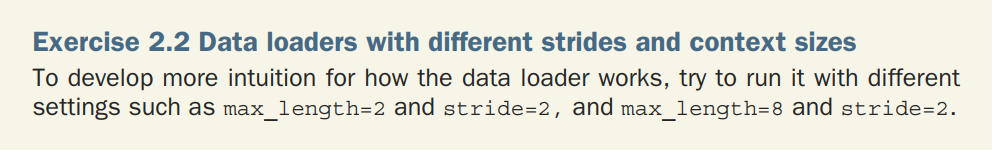

In [ ]:
dataloader_2 = create_dataloader_v1(data,batch_size=2,max_length=8,stride=2,shuffle=False)
data_iter_2 = iter(dataloader_2)
first_batch = next(data_iter_2)
second_batch = next(data_iter_2)

print(f"First batch :\n {first_batch}")
print(f"\n Second batch :\n {second_batch}")

Inputs :
 tensor([[   40.,   367.,  2885.,  1464.,  1807.,  3619.,   402.,   271.],
        [ 2885.,  1464.,  1807.,  3619.,   402.,   271., 10899.,  2138.]]) 

 Targets :
 tensor([[  367,  2885,  1464,  1807,  3619,   402,   271, 10899],
        [ 1464,  1807,  3619,   402,   271, 10899,  2138,   257]])


##### To Skip the overlapping between the batch and its next
- `we can set the max_length = stride`



In [325]:
dataloader_2 = create_dataloader_v1(data,batch_size=8,max_length=4,stride=4,shuffle=False)
data_iter_2 = iter(dataloader_2)
first_batch_inputs, first_batch_targets = next(data_iter_2)
#second_batch_inputs, second_batch_targets = next(data_iter_2)

print(f"Inputs :\n {first_batch_inputs} ")
print(f"\n Targets :\n {first_batch_targets}")

Inputs :
 tensor([[4.0000e+01, 3.6700e+02, 2.8850e+03, 1.4640e+03],
        [1.8070e+03, 3.6190e+03, 4.0200e+02, 2.7100e+02],
        [1.0899e+04, 2.1380e+03, 2.5700e+02, 7.0260e+03],
        [1.5632e+04, 4.3800e+02, 2.0160e+03, 2.5700e+02],
        [9.2200e+02, 5.8910e+03, 1.5760e+03, 4.3800e+02],
        [5.6800e+02, 3.4000e+02, 3.7300e+02, 6.4500e+02],
        [1.0490e+03, 5.9750e+03, 2.8400e+02, 5.0200e+02],
        [2.8400e+02, 3.2850e+03, 3.2600e+02, 1.1000e+01]]) 

 Targets :
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


# Embedding Layer

- We will convert the token_id into embedding 

In [332]:
# For simplicity --> lets consider that the vocab size = 6 , embed_dim = 3
# embed_dim --> each token will has embedding vector of 3 dim

vocab_size = 6
embed_dim =3
torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size , embed_dim)


In [333]:
# these embedding values are initialized randomly
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


> Embedding layer are weight matrix that optimized overtime using backpropagation 

#### Returning embedding vector of specific row `word`

In [334]:
embedding_layer(torch.tensor([3]))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)

#### Converting Ids into Embedding vector

In [336]:
input_ids = torch.tensor([2,3,5,1])
print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


#### Realistic Values

- `The BPE vocab size = 50257, because this tokenizer is used for ChatGPT`

In [343]:
vocab_size = 50257
output_dim = 256

token_embedding_layer = torch.nn.Embedding(vocab_size,output_dim)


In [341]:
max_length = 4
dataloader = create_dataloader_v1(data, batch_size=8,max_length=4,stride=max_length , shuffle=False)

data_iter = iter(dataloader)

inputs , targets = next(data_iter)

print(f"Token IDs: \n{inputs}")
print(f"Input Shape : {inputs.shape}")

Token IDs: 
tensor([[4.0000e+01, 3.6700e+02, 2.8850e+03, 1.4640e+03],
        [1.8070e+03, 3.6190e+03, 4.0200e+02, 2.7100e+02],
        [1.0899e+04, 2.1380e+03, 2.5700e+02, 7.0260e+03],
        [1.5632e+04, 4.3800e+02, 2.0160e+03, 2.5700e+02],
        [9.2200e+02, 5.8910e+03, 1.5760e+03, 4.3800e+02],
        [5.6800e+02, 3.4000e+02, 3.7300e+02, 6.4500e+02],
        [1.0490e+03, 5.9750e+03, 2.8400e+02, 5.0200e+02],
        [2.8400e+02, 3.2850e+03, 3.2600e+02, 1.1000e+01]])
Input Shape : torch.Size([8, 4])


In [351]:
inputs = torch.tensor(inputs, dtype=torch.long)
inputs

C:\Users\omark\AppData\Local\Temp\ipykernel_4028\2996443896.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = torch.tensor(inputs, dtype=torch.long)


tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

In [352]:
token_embedding = token_embedding_layer(inputs)
print(token_embedding.shape)

torch.Size([8, 4, 256])


### Full code for the embeddings

In [ ]:
torch.arange(3)

tensor([0, 1, 2])

In [358]:
context_length = max_length =4

# Embeddings for the 4 words (4,256)
pos_embedding_layer = torch.nn.Embedding(context_length,256)
pos_embeddings = pos_embedding_layer(torch.arange(context_length))

print(f"Positional Embeddings :\n {pos_embeddings}")
print(f"Shape of the Positional Embeddings : {pos_embeddings.shape}")




Positional Embeddings :
 tensor([[ 1.0616, -1.7385, -0.1369,  ...,  0.2940,  0.1641,  0.6888],
        [-1.1704, -0.7534,  1.0558,  ...,  0.7207, -1.1450,  0.4257],
        [-0.4962, -2.3787,  0.5664,  ..., -1.4357, -1.0299, -1.7057],
        [-0.2889, -2.4692,  0.4342,  ..., -0.8062, -0.1926, -0.0720]],
       grad_fn=<EmbeddingBackward0>)
Shape of the Positional Embeddings : torch.Size([4, 256])


## Broadcasting

- Since the embeddings layer [8,4,256]
- And the Positional Embeddings [4,256]

**Pytorch broadcasting technique: where it add the positional embeddings [4,256] for every batch**.
- `Resulting [8,4,256]`


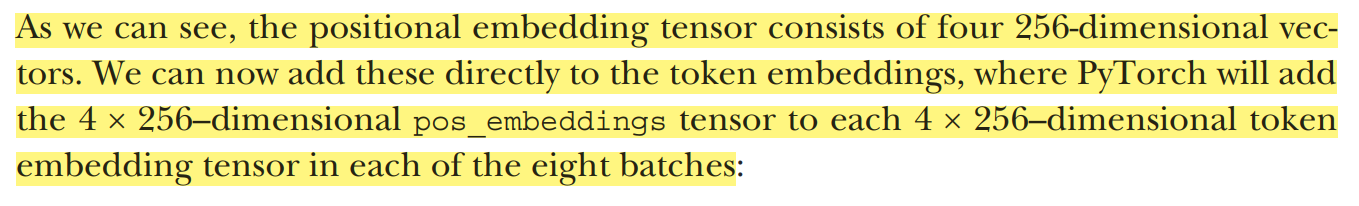

In [360]:
input_embeddings = token_embedding + pos_embeddings
print(f"Shape of the input embeddings : {input_embeddings.shape}")

Shape of the input embeddings : torch.Size([8, 4, 256])
